# 3. Análisis Exploratorio de Datos (EDA)
## TFM — Predicción del riesgo de readmisión hospitalaria en pacientes diabéticos

Dataset: *Diabetes 130-US Hospitals for Years 1999-2008* (UCI Machine Learning Repository).

En este notebook iremos construyendo el EDA paso a paso, sección por sección, siguiendo el índice de la propuesta:

1. Carga de datos y primer vistazo
2. Análisis descriptivo univariante y bivariante
3. Distribución de la variable objetivo (desbalanceo de clases)
4. Relación entre variables clínicas/demográficas y readmisión
5. Detección de valores ausentes, outliers e inconsistencias

## 3.1 Carga de librerías y del dataset

Empezamos importando las librerías que vamos a necesitar para esta primera fase (manejo de datos y visualización básica) y cargando el CSV en un DataFrame de pandas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')

In [2]:
# pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

# id=296 -> Diabetes 130-US Hospitals for Years 1999-2008
dataset = fetch_ucirepo(id=296)

X = dataset.data.features      # variables predictoras
y = dataset.data.targets       # variable "readmitted"

# metadatos y cita
print(dataset.metadata.additional_info.summary)
print(dataset.variables)

The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. It includes over 50 features representing patient and hospital outcomes. Information was extracted from the database for encounters that satisfied the following criteria.
(1)	It is an inpatient encounter (a hospital admission).
(2)	It is a diabetic encounter, that is, one during which any kind of diabetes was entered into the system as a diagnosis.
(3)	The length of stay was at least 1 day and at most 14 days.
(4)	Laboratory tests were performed during the encounter.
(5)	Medications were administered during the encounter.

The data contains such attributes as patient number, race, gender, age, admission type, time in hospital, medical specialty of admitting physician, number of lab tests performed, HbA1c test result, diagnosis, number of medications, diabetic medications, number of outpatient, inpatient, and emergency visits in the year before the hospitalization, etc.
  

C:\Users\lballi01\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\ucimlrepo\fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [3]:
# Unimos en un único DataFrame para trabajar cómodamente
df = pd.concat([dataset.data.ids, X, y], axis=1)

print(f"Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")

Filas: 101,766  |  Columnas: 50


In [4]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

## Conclusiones del primer análisis exploratorio (carga y estructura del dataset)

**1. Estructura general**

- El dataset contiene **101.766 filas** (encuentros hospitalarios) y **50 columnas**.
- 13 variables numéricas (`int64`) y 37 categóricas/texto (`object`). Muchas de estas últimas son en realidad categóricas de pocos niveles (medicamentos con valores `No/Steady/Up/Down`, género, etc.), no texto libre.

**2. Valores ausentes**

Gracias al uso de `ucimlrepo`, los valores ausentes ya vienen codificados como `NaN` (en el CSV original de UCI se representan con el carácter `"?"`).

| Columna | % ausente | Comentario |
|---|---|---|
| `weight` | 96.9% | Prácticamente inutilizable tal cual; candidata a eliminar o convertir en indicador binario ("¿se registró peso?"). |
| `max_glu_serum` | 94.8% | Solo se realizó esta prueba a ~5% de los pacientes. |
| `A1Cresult` | 83.3% | Prueba minoritaria, pero clínicamente relevante para diabetes. |
| `medical_specialty` | 49.1% | Casi la mitad de los registros sin especialidad médica asociada. |
| `payer_code` | 39.6% | Ausencia considerable; poca relevancia clínica esperada. |
| `race` | 2.2% | Ausencia baja, fácilmente tratable (imputación o eliminación de filas). |
| `diag_3` | 1.4% | Ausencia baja. |
| `diag_2` | 0.35% | Ausencia muy baja. |
| `diag_1` | 0.02% | Prácticamente completa. |

El resto de columnas (variables numéricas, fármacos, `readmitted`, etc.) no presentan valores ausentes.

**3. Primeras decisiones que se derivan de este análisis** *(a formalizar en la sección de Preparación y transformación de datos)*

- `weight`: candidata a eliminar o transformar en variable binaria, dado su altísimo porcentaje de ausencia (97%).
- `max_glu_serum` y `A1Cresult`: pese a su alta tasa de ausencia, no deben descartarse sin más — son clínicamente relevantes en diabetes, y el hecho de que "no se haya realizado la prueba" puede ser en sí mismo informativo. Se tratarán probablemente mediante una categoría explícita tipo `"No testeado"`.
- `payer_code`: buena candidata a eliminación por su bajo valor predictivo esperado.
- `medical_specialty`: caso intermedio; se valorará agrupar en categorías amplias (p. ej. "Cardiología", "Medicina Familiar", "Desconocido") en lugar de descartarla directamente.

Esta cuantificación de valores ausentes constituye la base del apartado de "detección de valores ausentes, outliers e inconsistencias" del EDA.

## 3.2 Análisis descriptivo univariante
### Variables numéricas

Antes de analizar las distribuciones en detalle, se separan del conjunto las columnas que no son magnitudes numéricas reales, para evitar interpretaciones erróneas:

- **Identificadores puros** (`encounter_id`, `patient_nbr`): no aportan valor analítico, se excluyen del análisis descriptivo.
- **Códigos categóricos** (`admission_type_id`, `discharge_disposition_id`, `admission_source_id`): aunque son de tipo numérico, en realidad codifican categorías (tipo de ingreso, tipo de alta, origen del ingreso). Se excluyen de este bloque numérico y se analizarán más adelante como variables categóricas, idealmente traduciendo sus códigos mediante el fichero de mapeo `IDs_mapping.csv` que proporciona UCI.

In [7]:
id_cols = ['encounter_id', 'patient_nbr']
coded_categorical_cols = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']

df.drop(columns=id_cols + coded_categorical_cols).describe().round(2)

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00
mean,4.40,43.10,1.34,16.02,0.37,0.20,0.64,7.42
std,2.99,19.67,1.71,8.13,1.27,0.93,1.26,1.93
min,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00
25%,2.00,31.00,0.00,10.00,0.00,0.00,0.00,6.00
50%,4.00,44.00,1.00,15.00,0.00,0.00,0.00,8.00
75%,6.00,57.00,2.00,20.00,0.00,0.00,1.00,9.00
max,14.00,132.00,6.00,81.00,42.00,76.00,21.00,16.00


**Conclusiones**

- El resto de variables numéricas (`time_in_hospital`, `num_lab_procedures`, `num_procedures`, `num_medications`, `number_diagnoses`) presentan distribuciones razonables, sin valores negativos ni absurdos, y con medias y medianas relativamente próximas — buena señal de calidad de los datos.
- `number_outpatient`, `number_emergency` y `number_inpatient` muestran una **asimetría muy marcada**: mediana igual a 0 en las tres, frente a máximos de 42, 76 y 21 respectivamente. Esto es característico de variables de "conteo de eventos raros": la mayoría de pacientes no presenta ningún evento previo de este tipo, pero existe una cola de casos con valores muy elevados.
- Estos valores extremos no deben tratarse automáticamente como errores o outliers a eliminar: es plausible que un paciente con un número muy alto de visitas a urgencias previas sea un caso clínico real y, además, especialmente predictivo de cara a la readmisión. Se decidirá su tratamiento definitivo (transformación, capping, o conservación tal cual) en la fase de preparación de datos, tras analizar su relación con la variable objetivo.
- No se observan valores imposibles (negativos, fuera de rango esperado) en ninguna de las variables numéricas analizadas.

### Variables categóricas demográficas

Se analizan las tres variables que caracterizan al paciente: `race`, `gender` y `age`.

In [10]:
df['race'].value_counts(dropna=False)

race
Caucasian          76099
AfricanAmerican    19210
NaN                 2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

In [11]:
df['gender'].value_counts(dropna=False)

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

In [12]:
df['age'].value_counts().sort_index()

age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64

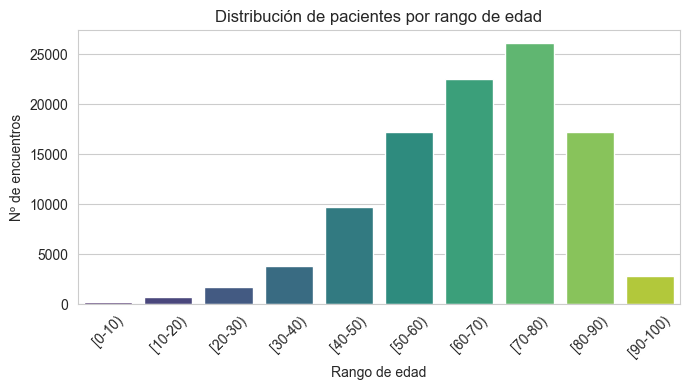

In [13]:
sns.set_style('whitegrid')

order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
         '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x='age', order=order, hue='age', legend=False, palette='viridis')
plt.title('Distribución de pacientes por rango de edad')
plt.xlabel('Rango de edad')
plt.ylabel('Nº de encuentros')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Conclusiones**

- **`race`**: la variable está fuertemente dominada por `Caucasian` (74.8%) y `AfricanAmerican` (18.9%), que conjuntamente representan ~94% de los registros. Los grupos restantes (`Hispanic`, `Other`, `Asian`) presentan un tamaño muestral reducido (0.6%–2%), lo que limita el análisis diferenciado sobre ellos. Presenta un 2.2% de valores ausentes, porcentaje bajo y fácilmente tratable.

- **`gender`**: distribución razonablemente equilibrada (53.8% mujeres, 46.2% hombres). Se detectan 3 registros con valor `Unknown/Invalid`, una cantidad marginal (0.003%) que se eliminará en la fase de preparación de datos sin impacto relevante sobre el conjunto.

- **`age`**: la variable se codifica en rangos de 10 años (decisión típica de anonimización en datasets clínicos), no como edad exacta. La distribución está claramente concentrada en edades avanzadas, con pico en el rango `[70-80)` (26.068 casos), y muy pocos casos en los extremos (`[0-10)`: 161; `[90-100)`: 2.793). Este patrón es coherente con el perfil epidemiológico esperado de la diabetes tipo 2, de mayor prevalencia en población de edad avanzada.

**Consideración para la fase de modelización**: al ser `age` una variable ordinal por rangos, existen dos aproximaciones posibles para su tratamiento posterior: mantenerla como categórica ordinal, o convertirla a numérica utilizando el punto medio de cada rango (5, 15, 25, ...). La decisión se tomará en la sección de preparación y transformación de datos.

### Variables Categóricas clínicas codificadas
Las columnas `admission_type_id`, `discharge_disposition_id` y `admission_source_id` son códigos categóricos, no magnitudes numéricas (ver apartado 3.1). Para poder interpretarlas correctamente, se traducen sus códigos a su significado real utilizando el fichero de mapeo `IDs_mapping.csv` proporcionado por UCI junto al dataset.

In [20]:
admission_type_map = pd.read_csv('../data/IDS_mapping - admission_type.csv')
discharge_disposition_map = pd.read_csv('../data/IDS_mapping - discharge_disposition.csv')
admission_source_map = pd.read_csv('../data/IDS_mapping - admission_source.csv')

type_dict = dict(zip(admission_type_map['admission_type_id'].astype(str),
                      admission_type_map['description']))
discharge_dict = dict(zip(discharge_disposition_map['discharge_disposition_id'].astype(str),
                           discharge_disposition_map['description']))
source_dict = dict(zip(admission_source_map['admission_source_id'].astype(str),
                        admission_source_map['description']))

print(type_dict)
print(discharge_dict)
print(source_dict)

{'1': 'Emergency', '2': 'Urgent', '3': 'Elective', '4': 'Newborn', '5': 'Not Available', '6': nan, '7': 'Trauma Center', '8': 'Not Mapped'}
{'1': 'Discharged to home', '2': 'Discharged/transferred to another short term hospital', '3': 'Discharged/transferred to SNF', '4': 'Discharged/transferred to ICF', '5': 'Discharged/transferred to another type of inpatient care institution', '6': 'Discharged/transferred to home with home health service', '7': 'Left AMA', '8': 'Discharged/transferred to home under care of Home IV provider', '9': 'Admitted as an inpatient to this hospital', '10': 'Neonate discharged to another hospital for neonatal aftercare', '11': 'Expired', '12': 'Still patient or expected to return for outpatient services', '13': 'Hospice / home', '14': 'Hospice / medical facility', '15': 'Discharged/transferred within this institution to Medicare approved swing bed', '16': 'Discharged/transferred/referred another institution for outpatient services', '17': 'Discharged/transferr

In [21]:
df['admission_type_desc'] = df['admission_type_id'].astype(str).map(type_dict)
df['discharge_disposition_desc'] = df['discharge_disposition_id'].astype(str).map(discharge_dict)
df['admission_source_desc'] = df['admission_source_id'].astype(str).map(source_dict)

In [23]:
df['admission_type_desc'].value_counts(dropna=False)

admission_type_desc
Emergency        53990
Elective         18869
Urgent           18480
NaN               5291
Not Available     4785
Not Mapped         320
Trauma Center       21
Newborn             10
Name: count, dtype: int64

In [24]:
df['discharge_disposition_desc'].value_counts(dropna=False)

discharge_disposition_desc
Discharged to home                                                                                           60234
Discharged/transferred to SNF                                                                                13954
Discharged/transferred to home with home health service                                                      12902
NaN                                                                                                           3701
Discharged/transferred to another short term hospital                                                         2128
Discharged/transferred to another rehab fac including rehab units of a hospital .                             1993
Expired                                                                                                       1642
Discharged/transferred to another type of inpatient care institution                                          1184
Not Mapped                                           

In [25]:
df['admission_source_desc'].value_counts(dropna=False)

admission_source_desc
 Emergency Room                                               57494
 Physician Referral                                           29565
NaN                                                            6781
Transfer from a hospital                                       3187
 Transfer from another health care facility                    2264
Clinic Referral                                                1104
 Transfer from a Skilled Nursing Facility (SNF)                 855
HMO Referral                                                    187
 Not Mapped                                                     161
 Not Available                                                  125
 Court/Law Enforcement                                           16
 Transfer from hospital inpt/same fac reslt in a sep claim       12
 Transfer from critial access hospital                            8
 Extramural Birth                                                 2
Normal Delivery           

**Conclusiones**

- **`admission_type_desc`**: predominan claramente los ingresos de tipo `Emergency` (53%), seguidos de `Elective` y `Urgent` en proporciones similares (~18% cada uno).
- **`admission_source_desc`**: coherente con lo anterior, el origen mayoritario es `Emergency Room` (56%), seguido de `Physician Referral` (29%). Entre ambos concentran el 85% de los ingresos.
- **`discharge_disposition_desc`**: la mayoría de pacientes son dados de alta a casa (`Discharged to home`, ~59%), seguido de transferencias a centros de cuidado continuado.
- **Hallazgo relevante para la fase de preparación de datos**: se detectan **1.642 casos (`Expired`)** correspondientes a pacientes fallecidos durante el ingreso. Estos casos no pueden ser readmitidos por definición, por lo que su valor de `readmitted = "NO"` no refleja una ausencia real de riesgo, sino una imposibilidad estructural. Se recomienda **excluir estas filas** antes de la fase de modelización, para evitar introducir sesgo en el aprendizaje del modelo.
- **Nota técnica sobre el fichero de mapeo**: los códigos cuya descripción original es el texto `"NULL"` (p. ej. `admission_type_id = 6`) se interpretan automáticamente por pandas como valores ausentes (`NaN`) al leer el CSV, aunque en realidad constituyen una categoría propia del dataset ("tipo/origen/destino sin especificar"). Se recomienda tratarlos como una categoría explícita (`"Sin especificar"`) en lugar de como ausencia real de dato, en la fase de preparación de datos.

### Variables categóricas restantes

In [31]:
# df['payer_code'].value_counts(dropna=False).head(15)
# df['medical_specialty'].value_counts(dropna=False).head(15)
# df['max_glu_serum'].value_counts(dropna=False)
# df['A1Cresult'].value_counts(dropna=False)
# df['change'].value_counts(dropna=False)
# df['diabetesMed'].value_counts(dropna=False)
# df['weight'].value_counts(dropna=False)

In [29]:
med_cols = ['metformin','repaglinide','nateglinide','chlorpropamide','glimepiride',
            'acetohexamide','glipizide','glyburide','tolbutamide','pioglitazone',
            'rosiglitazone','acarbose','miglitol','troglitazone','tolazamide',
            'examide','citoglipton','insulin','glyburide-metformin','glipizide-metformin',
            'glimepiride-pioglitazone','metformin-rosiglitazone','metformin-pioglitazone']

for col in med_cols:
    print(col, df[col].value_counts(normalize=True).round(3).to_dict())

metformin {'No': 0.804, 'Steady': 0.18, 'Up': 0.01, 'Down': 0.006}
repaglinide {'No': 0.985, 'Steady': 0.014, 'Up': 0.001, 'Down': 0.0}
nateglinide {'No': 0.993, 'Steady': 0.007, 'Up': 0.0, 'Down': 0.0}
chlorpropamide {'No': 0.999, 'Steady': 0.001, 'Up': 0.0, 'Down': 0.0}
glimepiride {'No': 0.949, 'Steady': 0.046, 'Up': 0.003, 'Down': 0.002}
acetohexamide {'No': 1.0, 'Steady': 0.0}
glipizide {'No': 0.875, 'Steady': 0.112, 'Up': 0.008, 'Down': 0.006}
glyburide {'No': 0.895, 'Steady': 0.091, 'Up': 0.008, 'Down': 0.006}
tolbutamide {'No': 1.0, 'Steady': 0.0}
pioglitazone {'No': 0.928, 'Steady': 0.069, 'Up': 0.002, 'Down': 0.001}
rosiglitazone {'No': 0.937, 'Steady': 0.06, 'Up': 0.002, 'Down': 0.001}
acarbose {'No': 0.997, 'Steady': 0.003, 'Up': 0.0, 'Down': 0.0}
miglitol {'No': 1.0, 'Steady': 0.0, 'Down': 0.0, 'Up': 0.0}
troglitazone {'No': 1.0, 'Steady': 0.0}
tolazamide {'No': 1.0, 'Steady': 0.0, 'Up': 0.0}
examide {'No': 1.0}
citoglipton {'No': 1.0}
insulin {'No': 0.466, 'Steady': 0.303

In [34]:
# df['diag_1'].nunique()  # -> 716
# df['diag_2'].nunique()  # -> 748
# df['diag_3'].nunique()  # -> 789

# df['diag_1'].value_counts().head(10)

**Administrativas/organizativas**

**`payer_code`** presenta 17 categorías, con `MC` (Medicare) como valor claramente predominante entre los casos con dato. Se trata de información administrativa (forma de pago), sin relación clínica directa esperable con la readmisión del paciente. Combinado con su elevado porcentaje de ausencia (39.6%), se recomienda **descartar esta variable** del análisis de modelización, documentando la decisión y su justificación.

**`medical_specialty`** presenta una cardinalidad muy elevada (72 categorías distintas), de las cuales 20 tienen menos de 10 casos, lo que las convierte en ruido estadístico si se tratan de forma individual. Las tres especialidades más frecuentes (`InternalMedicine`, `Emergency/Trauma`, `Family/GeneralPractice`) tienen coherencia clínica, al ser las especialidades generalistas más habituales en el ingreso de pacientes diabéticos. A diferencia de `payer_code`, esta variable sí resulta clínicamente relevante, por lo que no se recomienda descartarla, sino **reducir su cardinalidad**: conservar las especialidades más frecuentes (p. ej., el top 10) y agrupar el resto en una categoría `"Other"`, incorporando además una categoría explícita `"Unknown"` para los valores ausentes, dado que su ausencia podría ser en sí misma informativa.

**Resultados de laboratorio (`max_glu_serum`, `A1Cresult`)**

Ambas variables presentan una elevada tasa de ausencia (94.8% y 83.3% respectivamente), que corresponde a pacientes a los que no se les realizó la prueba, no a un dato perdido por error. Entre los casos con resultado registrado, `A1Cresult` muestra que la mayoría de pacientes testeados presentan valores fuera de rango normal (`>8` y `>7` superan conjuntamente a `Norm`), lo cual es coherente con tratarse de una población hospitalizada por diabetes.

**Medicamentos (23 variables)**

Se observa una variabilidad muy dispar entre fármacos. `insulin` es, con diferencia, el medicamento con mayor uso y variación de dosis (53.4% de pacientes con algún registro distinto de "No"). El resto de fármacos presentan porcentajes de "No" crecientes según su especificidad, y un subconjunto relevante (`examide`, `citoglipton`, `acetohexamide`, `troglitazone`, `glimepiride-pioglitazone`, `metformin-rosiglitazone`, `metformin-pioglitazone`) son prácticamente **constantes** (>99.9% "No"), por lo que no aportan capacidad discriminativa y son candidatas claras a eliminarse en la fase de preparación de datos.

**`change` y `diabetesMed`**

Ambas son variables binarias equilibradas: en el 46.2% de los encuentros hubo cambio de medicación (`change`), y el 77% de los pacientes recibía medicación para la diabetes (`diabetesMed`). Ambas son, a priori, buenas candidatas predictoras por su relación directa con la gestión clínica del paciente.

**`weight`**

Confirma lo detectado en el primer vistazo: 96.9% de ausencia. Dado el volumen de datos perdidos, no resulta viable su imputación fiable; se recomienda **descartar la variable** o, alternativamente, transformarla en un indicador binario de "peso registrado / no registrado" si se sospecha que el propio hecho de registrarlo es informativo.

**Diagnósticos (`diag_1`, `diag_2`, `diag_3`)**

Son variables de cardinalidad extremadamente alta (716, 748 y 789 códigos ICD-9 distintos respectivamente), inviables para un tratamiento categórico directo (One-Hot Encoding generaría cientos de columnas dispersas). Los diagnósticos primarios más frecuentes (`428`: insuficiencia cardíaca; `414`: cardiopatía isquémica crónica; `786`: síntomas respiratorios) son coherentes con el perfil de comorbilidad esperado en pacientes diabéticos hospitalizados. Se recomienda para la fase de transformación **agrupar los códigos ICD-9 por capítulo/categoría clínica** (por ejemplo: enfermedades circulatorias, respiratorias, digestivas, diabetes, etc.) en lugar de usar el código individual, siguiendo el criterio empleado en la literatura de referencia sobre este dataset (Strack et al., 2014).

**Conclusión general del bloque**

Quedan identificadas varias variables candidatas a eliminación por baja o nula varianza (`examide`, `citoglipton`, `acetohexamide`, `troglitazone`, `glimepiride-pioglitazone`, `metformin-rosiglitazone`, `metformin-pioglitazone`, `weight`, `payer_code`), y una estrategia clara de reducción de cardinalidad para `medical_specialty` y `diag_1/2/3`, que se formalizarán en la sección de preparación y transformación de datos.

Con este bloque se completa el análisis descriptivo univariante de todas las variables categóricas del dataset.

## 3.6 Distribución de la variable objetivo (desbalanceo de clases)

**Variable original: `readmitted`**

In [38]:
df['readmitted'].value_counts()
df['readmitted'].value_counts(normalize=True).round(3) * 100

readmitted
NO     53.9
>30    34.9
<30    11.2
Name: proportion, dtype: float64

**Construcción del target binario**

De acuerdo con el planteamiento del TFM (predecir la readmisión dentro de los 30 días posteriores al alta), se define una variable binaria a partir de `readmitted`, agrupando las clases `NO` y `>30` como negativo, y `<30` como positivo:

In [39]:
df['readmitted_30d'] = (df['readmitted'] == '<30').astype(int)
df['readmitted_30d'].value_counts()
df['readmitted_30d'].value_counts(normalize=True).round(3) * 100

readmitted_30d
0    88.8
1    11.2
Name: proportion, dtype: float64

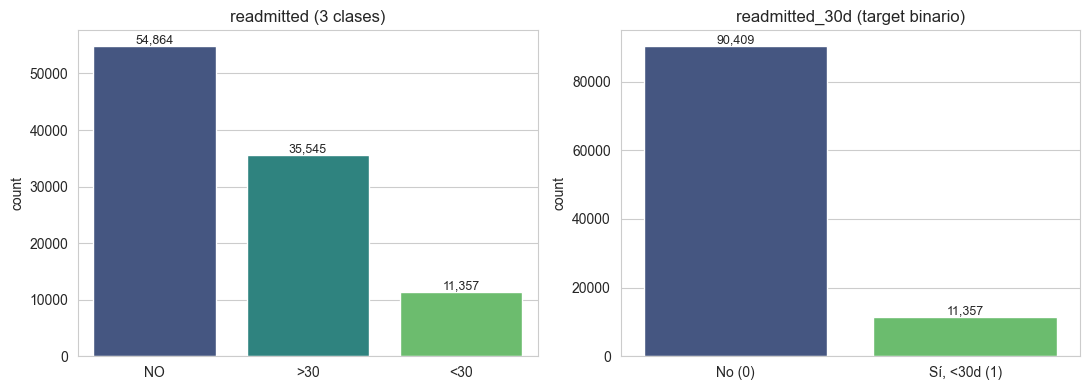

In [42]:
sns.set_style('whitegrid')

# Aseguramos que existe la variable binaria
df['readmitted_30d'] = (df['readmitted'] == '<30').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# --- Gráfico 1: readmitted original (3 clases) ---
order = ['NO', '>30', '<30']
ax0 = sns.countplot(data=df, x='readmitted', order=order,
                     hue='readmitted', legend=False, palette='viridis', ax=axes[0])
axes[0].set_title('readmitted (3 clases)')
axes[0].set_xlabel('')
for p in ax0.patches:
    ax0.annotate(f'{int(p.get_height()):,}',
                 (p.get_x() + p.get_width() / 2, p.get_height()),
                 ha='center', va='bottom', fontsize=9)

# --- Gráfico 2: readmitted_30d (target binario) ---
ax1 = sns.countplot(data=df, x='readmitted_30d',
                     hue='readmitted_30d', legend=False,
                     palette=['#3b528b', '#5ec962'], ax=axes[1])
axes[1].set_title('readmitted_30d (target binario)')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No (0)', 'Sí, <30d (1)'])
axes[1].set_xlabel('')
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height()):,}',
                 (p.get_x() + p.get_width() / 2, p.get_height()),
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**Conclusiones**

- La variable objetivo definitiva para el problema de clasificación es `readmitted_30d`, construida a partir de la variable original de tres niveles `readmitted`.
- Se observa un **desbalanceo de clases moderado**, con una proporción aproximada de **8:1** entre la clase mayoritaria (no readmitido en menos de 30 días) y la clase minoritaria de interés (readmitido en menos de 30 días).
- Este desbalanceo no es extremo, pero sí lo suficientemente relevante como para condicionar decisiones en la fase de modelización: métricas como el *accuracy* resultarían engañosas (un modelo que prediga siempre la clase mayoritaria alcanzaría un 88.8% de acierto sin ningún valor predictivo real), por lo que se priorizarán métricas como *recall*, *precision*, *F1-score* o *AUC-ROC*. Asimismo, se valorará el uso de técnicas específicas para el desbalanceo (`class_weight`, sobremuestreo/submuestreo) en la fase de modelización.

## 3.3 Análisis bivariante 


#### Tabla resumen de asociación con la variable objetivo

Antes de analizar cada variable en detalle, se calcula una medida de asociación entre cada variable predictora y `readmitted_30d`, con el objetivo de priorizar el análisis detallado sobre las variables con mayor relación potencial, en lugar de recorrer todas las variables de forma exhaustiva sin criterio.

Se utilizan dos medidas distintas según el tipo de variable:

- **Variables categóricas**: coeficiente de **Cramér's V**, calculado a partir del test de independencia chi-cuadrado. Se prefiere frente al p-valor del propio test porque, con un tamaño muestral de ~100.000 registros, prácticamente cualquier asociación resulta "estadísticamente significativa" aunque sea débil; Cramér's V aporta una medida del **tamaño del efecto**, comparable entre variables con distinto número de categorías (rango 0-1).
- **Variables numéricas**: coeficiente de correlación de **Spearman**, por ser más robusto que Pearson ante las distribuciones asimétricas detectadas en el análisis univariante (rango -1 a 1).

En ambos casos se excluyen previamente los registros con `discharge_disposition = "Expired"` (pacientes fallecidos durante el ingreso), dado que no pueden ser readmitidos por definición y distorsionarían cualquier medida de asociación calculada.

In [53]:
from scipy.stats import chi2_contingency, spearmanr

df_clean = df[df['discharge_disposition_desc'] != 'Expired'].copy()

def cramers_v(x, y):
    ct = pd.crosstab(x.astype(str), y)
    chi2, p, dof, exp = chi2_contingency(ct)
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt((chi2 / n) / min(k - 1, r - 1)), p

cat_vars = ['age', 'race', 'gender', 'admission_type_desc', 'discharge_disposition_desc',
            'admission_source_desc', 'medical_specialty', 'max_glu_serum', 'A1Cresult',
            'insulin', 'change', 'diabetesMed']

num_vars = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
            'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

results = []
for c in cat_vars:
    v, p = cramers_v(df_clean[c], df_clean['readmitted_30d'])
    results.append({'variable': c, 'tipo': 'categórica', 'medida': 'Cramér V', 'valor': round(v, 3), 'p_valor': p})

for c in num_vars:
    rho, p = spearmanr(df_clean[c], df_clean['readmitted_30d'])
    results.append({'variable': c, 'tipo': 'numérica', 'medida': 'Spearman rho', 'valor': round(rho, 3), 'p_valor': p})

res_df = pd.DataFrame(results).sort_values('valor', key=abs, ascending=False)

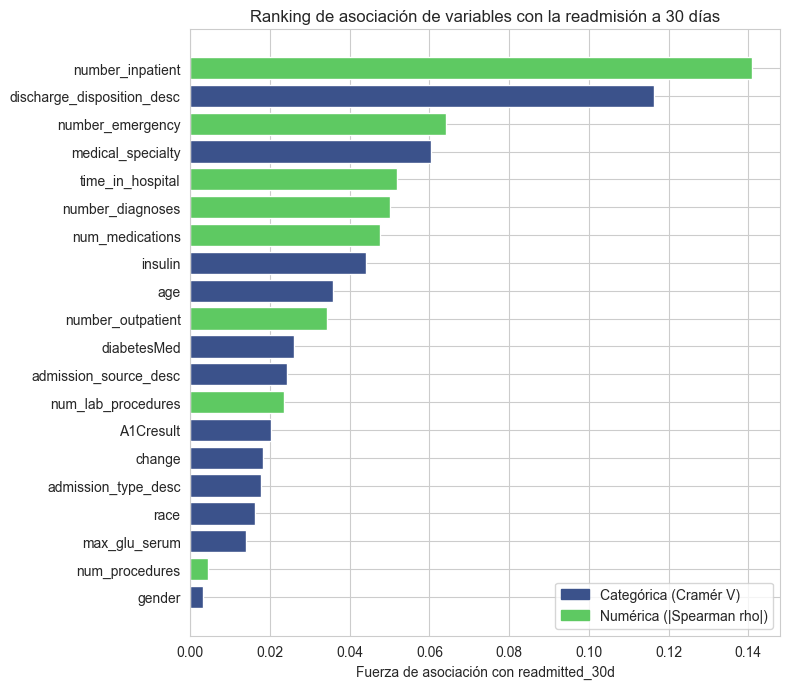

In [54]:
from matplotlib.patches import Patch


sns.set_style('whitegrid')

# Unimos las dos medidas (Cramér V y |Spearman|) en una sola tabla para poder graficarlas juntas
results = []
for c in cat_vars:
    v, p = cramers_v(df_clean[c], df_clean['readmitted_30d'])
    results.append({'variable': c, 'valor': v, 'tipo': 'Categórica (Cramér V)'})

for c in num_vars:
    rho, p = spearmanr(df_clean[c], df_clean['readmitted_30d'])
    results.append({'variable': c, 'valor': abs(rho), 'tipo': 'Numérica (|Spearman|)'})

res_df = pd.DataFrame(results).sort_values('valor', ascending=True)

plt.figure(figsize=(8, 7))
colors = res_df['tipo'].map({
    'Categórica (Cramér V)': '#3b528b',
    'Numérica (|Spearman|)': '#5ec962'
})
plt.barh(res_df['variable'], res_df['valor'], color=colors)
plt.xlabel('Fuerza de asociación con readmitted_30d')
plt.title('Ranking de asociación de variables con la readmisión a 30 días')
plt.legend(handles=[
    Patch(color='#3b528b', label='Categórica (Cramér V)'),
    Patch(color='#5ec962', label='Numérica (|Spearman rho|)')
], loc='lower right')
plt.tight_layout()
plt.show()

**Conclusiones**

- **`number_inpatient`** (número de ingresos hospitalarios previos) resulta ser la variable individual con mayor asociación con la readmisión a 30 días de todo el dataset, por encima incluso de variables clínicas más "evidentes" como los resultados de laboratorio. Tiene una interpretación clínica directa: el historial reciente de ingresos es el mejor predictor disponible del riesgo de un nuevo ingreso.
- **`discharge_disposition_desc`** se confirma como la segunda variable más relevante, validando el análisis detallado realizado previamente. Se señala, no obstante, que parte de esta asociación podría reflejar la complejidad clínica subyacente del paciente (a mayor complejidad, mayor necesidad de cuidado post-alta y mayor riesgo de readmisión) más que una relación causal directa del destino al alta en sí mismo.
- Las variables demográficas analizadas en detalle (`age`, `race`, `gender`) quedan confirmadas como de asociación débil o nula, coherente con las conclusiones ya alcanzadas en el apartado anterior. En particular, **`gender` no presenta asociación estadísticamente significativa** (p=0.582).
- **`num_procedures` tampoco resulta significativa** (p=0.167), siendo la única variable numérica sin relación aparente con el target.
- **Priorización para el resto del análisis bivariante**: se seleccionan para un análisis detallado con gráfico e interpretación clínica las variables `number_inpatient`, `number_emergency`, `medical_specialty`, `time_in_hospital`, `number_diagnoses` y `num_medications`. El resto de variables con asociación débil (`insulin`, `number_outpatient`, `diabetesMed`, `admission_source`, `num_lab_procedures`, `A1Cresult`, `admission_type`, `max_glu_serum`, `change`) se documentarán de forma agregada en la memoria, remitiendo al detalle completo en el Anexo. `num_procedures` y `gender` se consideran no relevantes para el análisis y candidatas a excluir del modelo.

### Relación entre `discharge_disposition` y la readmisión

Se analiza la tasa de readmisión a 30 días según el destino al alta del paciente. Previamente, se excluyen los registros correspondientes a pacientes fallecidos durante el ingreso (`discharge_disposition = "Expired"`, 1.642 casos), ya que estos no pueden ser readmitidos por definición y distorsionarían el cálculo de la tasa.

Filas antes de excluir Expired: 101766
Filas después: 100124
Filas excluidas: 1642
                                                    tasa_%      n
discharge_disposition_desc                                       
Discharged/transferred to another rehab fac inc...   27.70   1993
Discharged/transferred to another type of inpat...   20.86   1184
Discharged/transferred to another short term ho...   16.07   2128
Discharged/transferred to SNF                        14.66  13954
Discharged/transferred to ICF                        12.76    815
Discharged/transferred to home with home health...   12.70  12902
Discharged to home                                    9.30  60234
Not Mapped                                            9.30    989


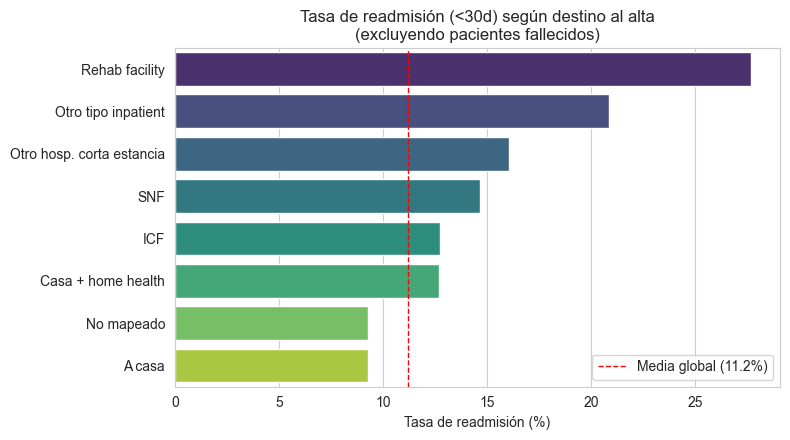

In [47]:
# Aplicamos el mapeo de discharge_disposition_id (ya calculado en el apartado 3.1)
df['discharge_disposition_desc'] = df['discharge_disposition_id'].astype(str).map(discharge_dict)
df['readmitted_30d'] = (df['readmitted'] == '<30').astype(int)

# Excluimos los pacientes fallecidos: no pueden ser readmitidos
print('Filas antes de excluir Expired:', len(df))
df_clean = df[df['discharge_disposition_desc'] != 'Expired'].copy()
print('Filas después:', len(df_clean))
print('Filas excluidas:', len(df) - len(df_clean))

# Nos quedamos con las categorías más frecuentes para el gráfico
top_disc = df_clean['discharge_disposition_desc'].value_counts().head(8).index
sub = df_clean[df_clean['discharge_disposition_desc'].isin(top_disc)]

rate = (sub.groupby('discharge_disposition_desc')['readmitted_30d'].mean() * 100).round(2)
n = sub.groupby('discharge_disposition_desc').size()
print(pd.DataFrame({'tasa_%': rate, 'n': n}).sort_values('tasa_%', ascending=False))

# Etiquetas cortas para que el gráfico sea legible
short_labels = {
    'Discharged/transferred to another rehab fac including rehab units of a hospital .': 'Rehab facility',
    'Discharged/transferred to another type of inpatient care institution': 'Otro tipo inpatient',
    'Discharged/transferred to another short term hospital': 'Otro hosp. corta estancia',
    'Discharged/transferred to SNF': 'SNF',
    'Discharged/transferred to ICF': 'ICF',
    'Discharged/transferred to home with home health service': 'Casa + home health',
    'Discharged to home': 'A casa',
    'Not Mapped': 'No mapeado'
}
df_clean['disc_short'] = df_clean['discharge_disposition_desc'].map(short_labels)
sub2 = df_clean[df_clean['disc_short'].isin(short_labels.values())]

rate_plot = sub2.groupby('disc_short')['readmitted_30d'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8, 4.5))
ax = sns.barplot(x=rate_plot.values, y=rate_plot.index,
                  hue=rate_plot.index, legend=False, palette='viridis')
plt.axvline(11.2, color='red', linestyle='--', linewidth=1, label='Media global (11.2%)')
plt.title('Tasa de readmisión (<30d) según destino al alta\n(excluyendo pacientes fallecidos)')
plt.xlabel('Tasa de readmisión (%)')
plt.ylabel('')
plt.legend()
plt.tight_layout()
plt.show()

**Conclusiones**

- Se observa una relación clara y con sentido clínico entre el destino al alta y el riesgo de readmisión: cuanto mayor es el nivel de cuidado post-alta requerido, mayor es la tasa de readmisión.
- Los pacientes dados de alta directamente a casa presentan la tasa más baja (9.3%), por debajo de la media global (11.2%), coherente con tratarse de los casos clínicamente menos complejos.
- Los pacientes transferidos a un centro de rehabilitación presentan la tasa más alta con diferencia (27.7%, prácticamente el triple que la media global), seguidos de transferencias a otras instituciones de cuidado inpatient (20.9%) y centros de enfermería especializada -SNF- (14.7%).
- Esta variable se perfila como una de las más predictivas del dataset analizadas hasta el momento, y confirma la relevancia de haber excluido previamente los casos de pacientes fallecidos, evitando así introducir una tasa de "no readmisión forzada" que habría distorsionado el análisis.